In [1]:
#!git clone https://github.com/lqiang67/rectified-flow.git
%cd rectified-flow/

/Users/saptarshiroy/Documents/GitHub/Low-dim-RF/rectified-flow


In [2]:
import torch
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import seaborn as sns

import torch.distributions as dist
import gmm 
from rectified_flow.utils import set_seed
from rectified_flow.utils import visualize_2d_trajectories_plotly
from rectified_flow.datasets.toy_gmm import TwoPointGMM

from rectified_flow.rectified_flow import RectifiedFlow
from rectified_flow.models.toy_mlp import MLPVelocityConditioned, MLPVelocity
from metric import calculate_discriminative_tv_qda
import json

set_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Setting parameters

In [3]:
from sklearn.datasets import make_moons
from data_generator import generate_data
from RFsampler_modules import geom_timegrid_generator, lin_timegrid_generator, MytrueEulerSampler, MynewSDE_timegrid_generator, Mynew_trueSDESampler
from RFmodules import VelocityNet
from tqdm import tqdm

DIMENSIONS = [int(i) for i in np.logspace(1, 2.9, num = 20)]
#####################################
n_samples = 50000
INPUT_DIM = 800
RANK = 8
CENTER = torch.ones(INPUT_DIM) * 8.0
TYPE = 'low_rank_Gaussian'  # 'low_rank_Gaussian' or 'two_moons'

NUM_STEPS = 100 # Number of time steps for sampling
NUM_SAMPLES = 2000 # Number of samples to Generate
#####################################





In [9]:
TV_geom_list = []
TV_lin_list = []
TV_sde_list = []
dimensions_list = []

for INPUT_DIM in DIMENSIONS:
    CENTER = torch.ones(INPUT_DIM) * 8.0
    

    # Original target distribution
    D1 = generate_data(TYPE, n_samples, INPUT_DIM, RANK, CENTER, device=device)

    TV_geom = []
    TV_lin = []
    TV_sde = []
    
    for rounds in tqdm(range(10), desc=f"DIM {INPUT_DIM}"):
       
        # print(f"Dimension: {INPUT_DIM}, Round: {rounds+1}")

        # generate data
        pi_0 = dist.MultivariateNormal(torch.zeros(INPUT_DIM, device=device), torch.eye(INPUT_DIM, device=device))
        D0 = pi_0.sample([n_samples])  

        
        
        # Fluff RF model
        straight_rf = RectifiedFlow(
            data_shape=(INPUT_DIM,),
            velocity_field=VelocityNet(INPUT_DIM, h_dim=128).to(device), # MLPVelocity(INPUT_DIM, hidden_sizes = [128] * 6).to(device)
            interp="straight",
            source_distribution=pi_0,
            device=device,
        )

        # generate trajectories using true velocity field
        
        
        true_euler_sampler_lin = MytrueEulerSampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
            time_grid = lin_timegrid_generator(NUM_STEPS),
            rectified_flow = straight_rf,
            num_samples= NUM_SAMPLES,
        )

        true_euler_sampler_geom = MytrueEulerSampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
            time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS)),
            rectified_flow = straight_rf,
            num_samples= NUM_SAMPLES,
        )

        true_traj1_geom = true_euler_sampler_geom.sample_loop(seed=rounds)
        true_traj1_lin = true_euler_sampler_lin.sample_loop(seed=rounds)

        true_sde_sampler = Mynew_trueSDESampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
            rectified_flow=straight_rf,
            time_grid = MynewSDE_timegrid_generator(NUM_STEPS , c0 = 2, c1 = 5), # 900, c0 = 5, c1 = 10.5
            num_samples= NUM_SAMPLES,
        )
        true_traj_sde = true_sde_sampler.sample_loop(seed=rounds)

        # Caluclate TV-QDA between generated samples and real data samples at a certain time step
        geom_time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS))
        lin_time_grid = lin_timegrid_generator(NUM_STEPS)
        sde_time_grid = MynewSDE_timegrid_generator(NUM_STEPS, c0 = 2, c1 = 5)
        pos  = 2  # Position in the time grid to evaluate
        blurred_Real_Data_geom = D1[:NUM_SAMPLES] * geom_time_grid[-pos] + D0[:NUM_SAMPLES] * (1 - geom_time_grid[-pos])
        blurred_Real_Data_lin = D1[:NUM_SAMPLES] * lin_time_grid[-pos] + D0[:NUM_SAMPLES] * (1 - lin_time_grid[-pos])
        blurred_Real_Data_sde = D1[:NUM_SAMPLES] * sde_time_grid[-1] + D0[:NUM_SAMPLES] * (1 - sde_time_grid[-1])

        blurred_Real_Data_geom = blurred_Real_Data_geom.cpu().numpy()  # Real data samples from distribution p_1
        blurred_Real_Data_lin = blurred_Real_Data_lin.cpu().numpy()  # Real data samples from distribution p_1
        blurred_Real_Data_sde = blurred_Real_Data_sde.cpu().numpy()  # Real data samples from distribution p_1

        Gen_Data_geom = true_traj1_geom.trajectories[-pos].cpu().numpy()  # Generated data samples from geometry time grid
        Gen_Data_lin = true_traj1_lin.trajectories[-pos].cpu().numpy()  # Generated data samples from linear time grid
        Gen_Data_sde = true_traj_sde.trajectories[-1].cpu().numpy()  # Generated data samples from SDE sampler
        
        tv_qda_geom = calculate_discriminative_tv_qda(blurred_Real_Data_geom, Gen_Data_geom)
        tv_qda_lin = calculate_discriminative_tv_qda(blurred_Real_Data_geom, Gen_Data_lin)
        tv_qda_sde = calculate_discriminative_tv_qda(blurred_Real_Data_sde, Gen_Data_sde)

        TV_geom.append(tv_qda_geom)
        TV_lin.append(tv_qda_lin)
        TV_sde.append(tv_qda_sde)

    TV_geom_list.append(np.mean(TV_geom))
    TV_lin_list.append(np.mean(TV_lin))
    TV_sde_list.append(np.mean(TV_sde))
    dimensions_list.append(INPUT_DIM)
    # save intermediate results as json
    
    results = {
        "DIMENSIONS": dimensions_list,
        "TV_geom_list": TV_geom_list,
        "TV_lin_list": TV_lin_list,
        "TV_sde_list": TV_sde_list,
    }
    #print(results)
    # create json file of specific name
    name = f"assets/N_{NUM_STEPS}_low_rank_Gaussian_TV_results.json"
    with open(name, "w") as f:
        json.dump(results, f)   

DIM 794: 100%|██████████| 10/10 [05:41<00:00, 34.18s/it]


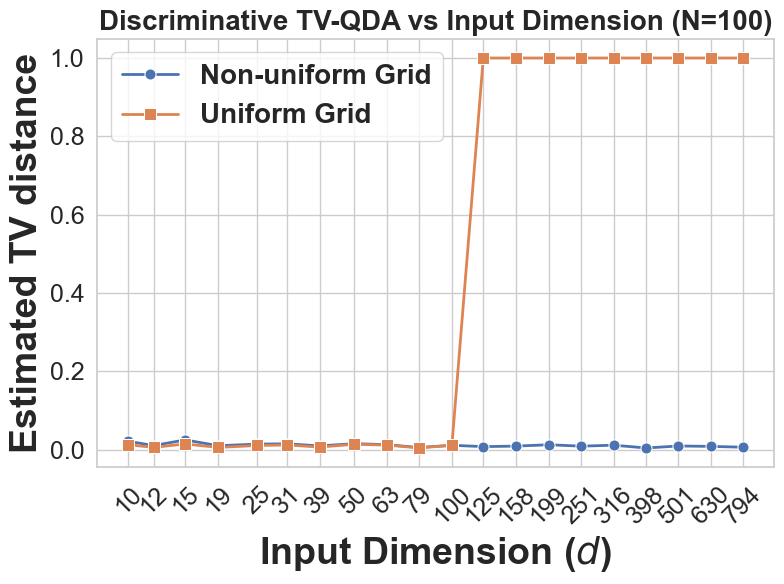

In [10]:
from matplotlib.ticker import LogLocator, ScalarFormatter
NUM_STEPS = 100
TITLE_FONT = 20
LEGEND_FONT = 20
AXIS_FONT = 18
AXIS_LABEL_FONT = 27
# import the .json file
with open(f"assets/N_{NUM_STEPS}_low_rank_Gaussian_TV_results.json", "r") as f:
    results = json.load(f)
DIMENSIONS = results["DIMENSIONS"]
TV_geom_list = results["TV_geom_list"]
TV_lin_list = results["TV_lin_list"]
TV_sde_list = results["TV_sde_list"]
# -----------------------------------------------------------------

# Set a seaborn style for better aesthetics (e.g., 'whitegrid' or 'darkgrid')
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

# 1. Plot the Geometric Time Grid data using sns.lineplot
# 'marker' and 'markersize' can be used like in matplotlib
sns.lineplot(
    x=DIMENSIONS,
    y=TV_geom_list,
    marker='o',
    label='Non-uniform Grid',
    markersize=8,
    linewidth=2
)

# 2. Plot the Linear Time Grid data using sns.lineplot
sns.lineplot(
    x=DIMENSIONS,
    y=TV_lin_list,
    marker='s',
    label='Uniform Grid',
    markersize=8,
    linewidth=2
)

# 3. Apply the scales and labels
plt.xscale('log')
ax = plt.gca()
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
# make x_ticks spreadout for better visibility
plt.xticks(DIMENSIONS, labels=[str(d) for d in DIMENSIONS])
plt.tick_params(axis='x', which='major', labelsize=AXIS_FONT, rotation=45, pad= 5)
plt.tick_params(axis='y', which='major', labelsize=AXIS_FONT)
# If you decide to re-enable the log scale for the Y-axis:
# plt.yscale('log')

plt.xlabel('Input Dimension ($d$)', fontsize=AXIS_LABEL_FONT, fontweight='bold')
# Use the raw string (r'...') to correctly render the LaTeX math expression
plt.ylabel(r'Estimated TV distance', fontsize= AXIS_LABEL_FONT, fontweight='bold')

plt.legend(prop = {'size': LEGEND_FONT, 'weight': 'bold'})
# make the title bold and larger
plt.title(f'Discriminative TV-QDA vs Input Dimension (N={NUM_STEPS})', fontsize=TITLE_FONT, fontweight='bold')


# Use plt.tight_layout() to ensure labels and title fit within the figure area
plt.tight_layout()


plt.savefig(f'assets/N_{NUM_STEPS}_low_rank_TV_vs_dimension.pdf', dpi=500)
plt.show()

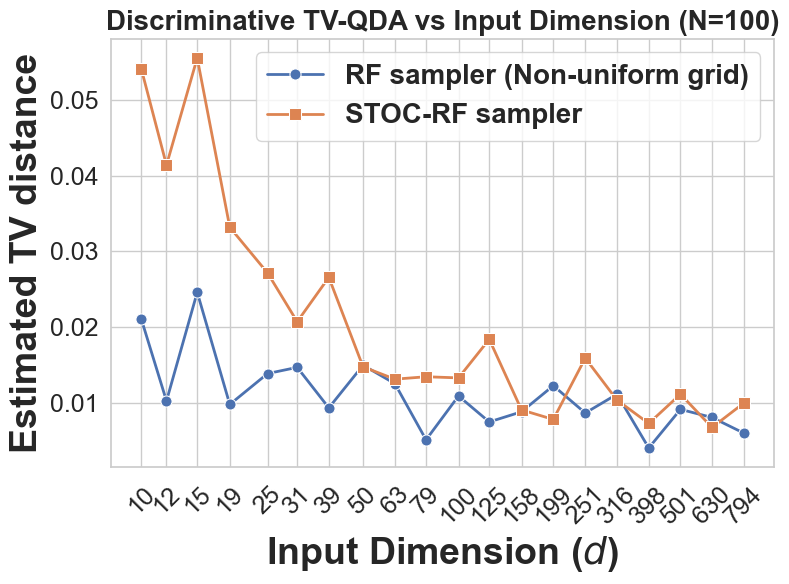

In [11]:
from matplotlib.ticker import LogLocator, ScalarFormatter
NUM_STEPS = 100
TITLE_FONT = 20
LEGEND_FONT = 20
AXIS_FONT = 18
AXIS_LABEL_FONT = 27
# import the .json file
with open(f"assets/N_{NUM_STEPS}_low_rank_Gaussian_TV_results.json", "r") as f:
    results = json.load(f)
DIMENSIONS = results["DIMENSIONS"]
TV_geom_list = results["TV_geom_list"]
TV_sde_list = results["TV_sde_list"]
# plot TV geom and TV sde
# Set a seaborn style for better aesthetics (e.g., 'whitegrid' or 'darkgrid')
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

# 1. Plot the Geometric Time Grid data using sns.lineplot
# 'marker' and 'markersize' can be used like in matplotlib
sns.lineplot(
    x=DIMENSIONS,
    y=TV_geom_list,
    marker='o',
    label='RF sampler (Non-uniform grid)',
    markersize=8,
    linewidth=2
)

# 2. Plot the SDE Time Grid data using sns.lineplot
sns.lineplot(
    x=DIMENSIONS,
    y=TV_sde_list,
    marker='s',
    label='STOC-RF sampler',
    markersize=8,
    linewidth=2
)

# 3. Apply the scales and labels
plt.xscale('log')
ax = plt.gca()
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
# make x_ticks spreadout for better visibility
plt.xticks(DIMENSIONS, labels=[str(d) for d in DIMENSIONS])
plt.tick_params(axis='x', which='major', labelsize=AXIS_FONT, rotation=45, pad= 5)
plt.tick_params(axis='y', which='major', labelsize=AXIS_FONT)
# If you decide to re-enable the log scale for the Y-axis:
#plt.yscale('log')

plt.xlabel('Input Dimension ($d$)', fontsize= AXIS_LABEL_FONT, fontweight='bold')
# Use the raw string (r'...') to correctly render the LaTeX math expression
plt.ylabel(r'Estimated TV distance', fontsize= AXIS_LABEL_FONT, fontweight='bold')

plt.legend(prop = {'size': LEGEND_FONT, 'weight': 'bold'})
plt.title(f'Discriminative TV-QDA vs Input Dimension (N={NUM_STEPS})', fontsize=TITLE_FONT, fontweight='bold')

# Use plt.tight_layout() to ensure labels and title fit within the figure area
plt.tight_layout()


plt.savefig(f'assets/N_{NUM_STEPS}_low_rank_TV(geom vs sde)_vs_dimension.pdf', dpi=500)
plt.show()

# Plotting KL distance

In [54]:
from metric import kl_divergence_gaussians

kl_geom_list = []
kl_lin_list = []

for INPUT_DIM in DIMENSIONS:
    CENTER = torch.ones(INPUT_DIM) * 8.0
    

    # Original target distribution
    D1 = generate_data(TYPE, n_samples, INPUT_DIM, RANK, CENTER, device=device)

    
    for rounds in tqdm(range(10), desc=f"DIM {INPUT_DIM}"):
        kl_geom = 0
        kl_lin = 0
        # print(f"Dimension: {INPUT_DIM}, Round: {rounds+1}")

        # generate data
        pi_0 = dist.MultivariateNormal(torch.zeros(INPUT_DIM, device=device), torch.eye(INPUT_DIM, device=device))
        D0 = pi_0.sample([n_samples])  

        
        
        # Fluff RF model
        straight_rf = RectifiedFlow(
            data_shape=(INPUT_DIM,),
            velocity_field=VelocityNet(INPUT_DIM, h_dim=128).to(device), # MLPVelocity(INPUT_DIM, hidden_sizes = [128] * 6).to(device)
            interp="straight",
            source_distribution=pi_0,
            device=device,
        )

        # generate trajectories using true velocity field
        
        
        true_euler_sampler_lin = MytrueEulerSampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
            time_grid = lin_timegrid_generator(NUM_STEPS),
            rectified_flow = straight_rf,
            num_samples= NUM_SAMPLES,
        )

        true_euler_sampler_geom = MytrueEulerSampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
            time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS)),
            rectified_flow = straight_rf,
            num_samples= NUM_SAMPLES,
        )

        true_traj1_geom = true_euler_sampler_geom.sample_loop(seed=100)
        true_traj1_lin = true_euler_sampler_lin.sample_loop(seed=100)


        # Caluclate TV-QDA between generated samples and real data samples at a certain time step
        geom_time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/max(INPUT_DIM, NUM_STEPS))
        lin_time_grid = lin_timegrid_generator(NUM_STEPS)
        pos  = 2  # Position in the time grid to evaluate
        blurred_Real_Data_geom = D1[:NUM_SAMPLES] * geom_time_grid[-pos] + D0[:NUM_SAMPLES] * (1 - geom_time_grid[-pos])
        blurred_Real_Data_lin = D1[:NUM_SAMPLES] * lin_time_grid[-pos] + D0[:NUM_SAMPLES] * (1 - lin_time_grid[-pos])
        blurred_Real_Data_geom = blurred_Real_Data_geom.cpu().numpy()  # Real data samples from distribution p_1
        blurred_Real_Data_lin = blurred_Real_Data_lin.cpu().numpy()  # Real data samples from distribution p_1
        Gen_Data_geom = true_traj1_geom.trajectories[-pos].cpu().numpy()  # Generated data samples from geometry time grid
        Gen_Data_lin = true_traj1_lin.trajectories[-pos].cpu().numpy()  # Generated data samples from linear time grid

        mean_real_geom = np.mean(blurred_Real_Data_geom, axis=0)
        cov_real_geom = np.cov(blurred_Real_Data_geom, rowvar=False)
        # mean_real_lin = np.mean(blurred_Real_Data_lin, axis=0)
        # cov_real_lin = np.cov(blurred_Real_Data_lin, rowvar=False)
        mean_gen_geom = np.mean(Gen_Data_geom, axis=0)
        cov_gen_geom = np.cov(Gen_Data_geom, rowvar=False)
        mean_gen_lin = np.mean(Gen_Data_lin, axis=0)
        cov_gen_lin = np.cov(Gen_Data_lin, rowvar=False)


        kl_geom = kl_divergence_gaussians(mean_real_geom, cov_real_geom, mean_gen_geom, cov_gen_geom)
        kl_lin = kl_divergence_gaussians(mean_real_geom, cov_real_geom, mean_gen_lin, cov_gen_lin)

        kl_geom += kl_geom
        kl_lin += kl_lin
    kl_geom_list.append(np.mean(kl_geom))
    kl_lin_list.append(np.mean(kl_lin))

DIM 10:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 16:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 26:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 42:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 69:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 113:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 184:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 300:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 488:   0%|          | 0/10 [00:00<?, ?it/s]

DIM 794:   0%|          | 0/10 [00:00<?, ?it/s]

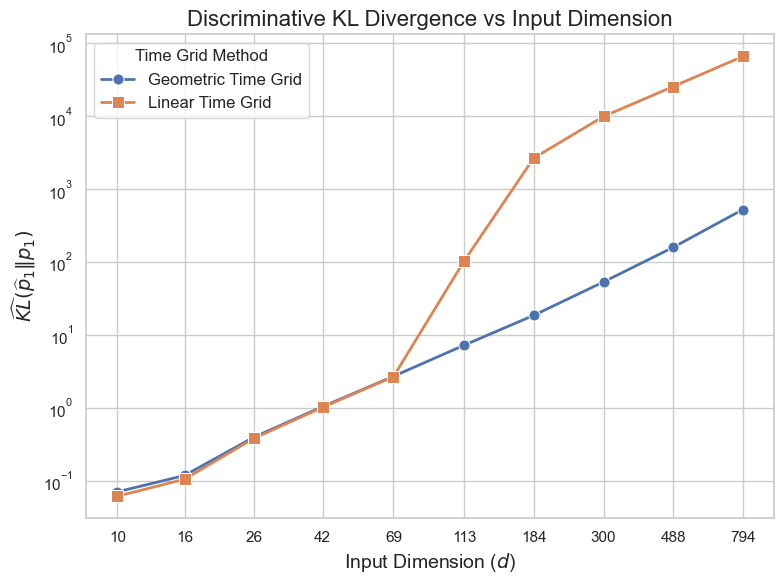

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# -----------------------------------------------------------------

# Set a seaborn style for better aesthetics (e.g., 'whitegrid' or 'darkgrid')
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

# 1. Plot the Geometric Time Grid data using sns.lineplot
# 'marker' and 'markersize' can be used like in matplotlib
sns.lineplot(
    x=DIMENSIONS,
    y=kl_geom_list,
    marker='o',
    label='Geometric Time Grid',
    markersize=8,
    linewidth=2
)

# 2. Plot the Linear Time Grid data using sns.lineplot
sns.lineplot(
    x=DIMENSIONS,
    y=kl_lin_list,
    marker='s',
    label='Linear Time Grid',
    markersize=8,
    linewidth=2
)

# 3. Apply the scales and labels
plt.xscale('log')
plt.xticks(DIMENSIONS, labels=[str(d) for d in DIMENSIONS])
# If you decide to re-enable the log scale for the Y-axis:
plt.yscale('log')

plt.xlabel('Input Dimension ($d$)', fontsize=14)
# Use the raw string (r'...') to correctly render the LaTeX math expression
plt.ylabel(r'$\widehat{KL}(\widehat{p}_1 \Vert p_1)$', fontsize=14)

plt.legend(fontsize=12, title='Time Grid Method')
plt.title('Discriminative KL Divergence vs Input Dimension', fontsize=16)

# Use plt.tight_layout() to ensure labels and title fit within the figure area
plt.tight_layout()


plt.savefig(f'assets/N_{NUM_STEPS}_low_rank_KL_vs_dimension.pdf', dpi=300)
plt.show()

In [15]:
MynewSDE_timegrid_generator(NUM_STEPS , c0 = 9, c1 = 10.5) + 1e-10

tensor([0.7232, 0.7634, 0.7986, 0.8293, 0.8560, 0.8789, 0.8985, 0.9153, 0.9294,
        0.9413, 0.9513, 0.9597, 0.9667, 0.9725, 0.9773, 0.9813, 0.9846, 0.9873,
        0.9896, 0.9914, 0.9929, 0.9942, 0.9952, 0.9961, 0.9968, 0.9974, 0.9978,
        0.9982, 0.9985, 0.9988, 0.9990, 0.9992, 0.9994, 0.9995, 0.9996, 0.9997,
        0.9998, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/var/folders/vn/wcs2tz697rb3rf5l0rfkyr4w0000gn/T/ipykernel_87906/254340788.py:10: SyntaxWarning: invalid escape sequence '\d'
  plt.title(f'Histogram of Non-uniform grid (N={NUM_STEPS}, $\delta$={round(delta, 3)})', fontsize=16)


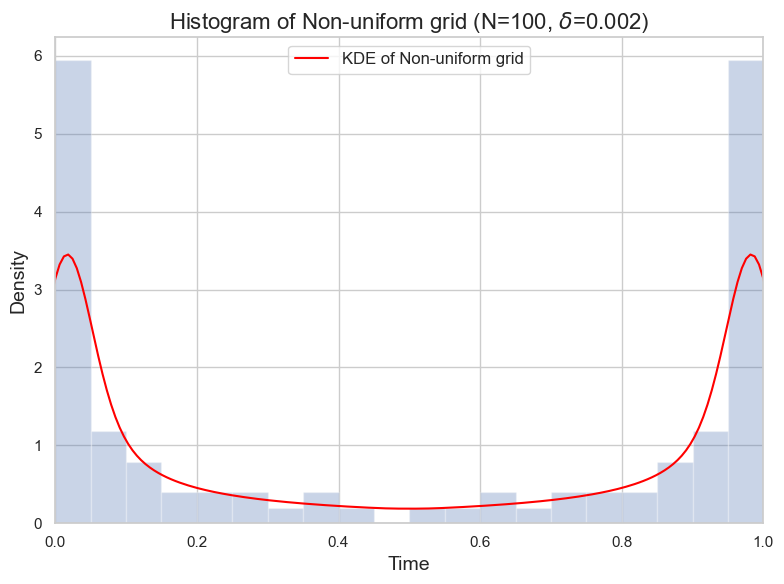

In [18]:
NUM_STEPS = 100 # 200
delta = 0.002 #1 / max(INPUT_DIM, NUM_STEPS)
timegrid  = geom_timegrid_generator(NUM_STEPS, delta=delta)
timegrid
# plot histogram of timegrid with kernal density estimation
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
sns.kdeplot(timegrid.cpu().numpy(), bw_adjust=0.2, color='red', label='KDE of Non-uniform grid')
plt.hist(timegrid.cpu().numpy(), bins=20, density=True, alpha=0.3)
plt.title(f'Histogram of Non-uniform grid (N={NUM_STEPS}, $\delta$={round(delta, 3)})', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xlim(0, 1)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(f'assets/N_{NUM_STEPS}_geom_timegrid_histogram.pdf', dpi=300)
plt.show()  

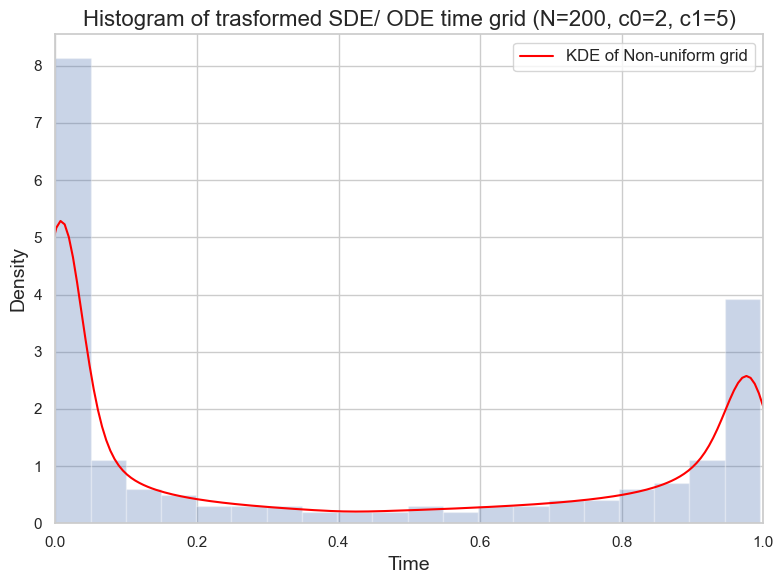

In [12]:
# Histogram for SDE time grid
timegrid_sde = MynewSDE_timegrid_generator(NUM_STEPS , c0 = 2, c1 = 5)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
sns.kdeplot(timegrid_sde.cpu().numpy(), bw_adjust=0.2, color='red', label='KDE of Non-uniform grid')
plt.hist(timegrid_sde.cpu().numpy(), bins=20, density=True, alpha=0.3)
plt.title(f'Histogram of trasformed SDE/ ODE time grid (N={NUM_STEPS}, c0={2}, c1={5})', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xlim(0, 1)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(f'assets/N_{NUM_STEPS}_sde_timegrid_histogram.pdf', dpi=300)
plt.show()